In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

from data.utils.fsdd import FSDD
from src.data.dataloader import dataUtils, FSDDDataset
from src.utils.config import Config
from src.data.feat_aug import Augmentation, feature_extraction
from src.trainer.trainer import train_model
from src.model.mymodel import MLPMTLModel
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader
import torch

In [2]:
# audio_dir="C:\\Users\\Ammar\\OneDrive\\Dokumen\\NextCloud\\My Documents\\Kuylah S2\\SEM 2\\RFPP\\RFPP_Task\\Last Project\\pseudo MTL\\data\\recordings\\"
# fsdd_tool = FSDD(audio_dir)

In [3]:
# spectr, label = fsdd_tool.get_spectrograms("C:\\Users\\Ammar\\OneDrive\\Dokumen\\NextCloud\\My Documents\\Kuylah S2\\SEM 2\\RFPP\\RFPP_Task\\Last Project\\pseudo MTL\\data\\spectrotest\\")
# print(len(spectr[0]))

In [4]:
DataUtils = dataUtils()
waveform_data = DataUtils.load_data_waveform(Config.AUDIO_PATH)
print(len(waveform_data))

3000


In [5]:
# print(waveform_data)

In [6]:
aug = Augmentation()

audio_augmentations = [
    lambda y, sr: aug.add_gaussian_noise(y, noise_factor=0.005),
    lambda y, sr: aug.time_shift(y, time_shift_max=0.2),
    lambda y, sr: aug.pitch_shift(y, sr, pitch_steps=[-1, 1]),
    lambda y, sr: aug.time_stretch(y, rate=1.1),
    lambda y, sr: aug.volume_scale(y, scale_range=(0.7, 1.3)),
]

augmented_waveform_data = aug.random_waveform_augmentation(audio_augmentations, waveform_data)

1456 data diaugmentasi


In [7]:
waveform_data.extend(augmented_waveform_data)
mfcc_data = feature_extraction(waveform_data)

In [8]:
print(mfcc_data)

[{'augmented': 0, 'speaker': 'george', 'digit': '0', 'sample_number': '0', 'mfcc_feature': array([ 6.07118236e-05,  8.88652578e-02,  3.16208839e-01, -2.87280589e-01,
        6.04717548e-02,  8.37253854e-02,  1.39007426e+03,  3.91326452e+02,
        1.11597213e+03,  2.21769729e+02,  2.62539438e+03,  7.35832387e+02,
       -1.55368347e+02,  1.15919174e+02, -4.18410568e+01,  4.22475128e+01,
        3.20735550e+01, -2.55104294e+01,  3.35551834e+00, -7.68906736e+00,
       -2.27011337e+01,  2.13735533e+00, -1.44706774e+01, -1.69169807e+01,
        7.37479973e+00, -3.46834683e+00, -6.50074244e+00,  3.88444042e+00,
       -1.97251248e+00,  1.12847829e+00,  1.48245132e+00, -4.86364412e+00,
        1.79738579e+01,  1.62294731e+01,  1.56230984e+01,  1.84653606e+01,
        1.37399178e+01,  9.47696495e+00,  5.13838673e+00,  6.43896627e+00,
        5.85224581e+00,  7.38846397e+00,  5.09878874e+00,  5.25741768e+00,
        3.08128953e+00,  6.01232719e+00,  5.96149921e+00,  3.02601218e+00,
        4

In [9]:
mfcc_df = pd.DataFrame(mfcc_data)
mfcc_df.head()

,augmented,speaker,digit,sample_number,mfcc_feature
0,0,george,0,0,"[6.071182360756211e-05, 0.0888652577996254, 0...."
1,0,george,0,1,"[-2.2823935069027357e-05, 0.05002695694565773,..."
2,0,george,0,10,"[-2.9235707188490778e-05, 0.04465978965163231,..."
3,0,george,0,11,"[-2.0361474525998347e-05, 0.047294557094573975..."
4,0,george,0,12,"[-1.4424660548684187e-05, 0.04648785665631294,..."


In [10]:
cols_to_fix = ['digit', 'sample_number'] 

mfcc_df[cols_to_fix] = mfcc_df[cols_to_fix].astype(int)

mfcc_df = mfcc_df.sort_values(
    by=['speaker', 'digit', 'sample_number'], 
    ascending=True
).reset_index(drop=True)

# mfcc_expanded = pd.DataFrame(
#     mfcc_df["mfcc_feature"].tolist(),
#     columns=[f"mfcc_feature_{i}" for i in range(len(mfcc_df["mfcc_feature"].iloc[0]))]
# )

# mfcc_df = pd.concat([mfcc_df.drop(columns=["mfcc_feature"]), mfcc_expanded], axis=1)
mfcc_df.head()

,augmented,speaker,digit,sample_number,mfcc_feature
0,0,george,0,0,"[6.071182360756211e-05, 0.0888652577996254, 0...."
1,0,george,0,1,"[-2.2823935069027357e-05, 0.05002695694565773,..."
2,1,george,0,1,"[-1.806826185202226e-05, 0.03960305452346802, ..."
3,0,george,0,2,"[-2.652477633091621e-05, 0.07252717018127441, ..."
4,1,george,0,2,"[-2.685034996829927e-05, 0.07035611569881439, ..."


In [11]:
train_data, test_data, val_data = DataUtils.data_split(mfcc_df)

In [12]:
le = LabelEncoder()
train_data['speaker_id'] = le.fit_transform(train_data['speaker'])
test_data['speaker_id'] = le.transform(test_data['speaker'])
val_data['speaker_id'] = le.transform(val_data['speaker'])

In [13]:
scaled = dataUtils.scale_features(train_data, val_data, test_data)

X_train = scaled['train']
X_val   = scaled['val']
X_test  = scaled['test']
scaler  = scaled['scaler']  # simpan untuk inference nanti

In [14]:
# mfcc_augmentations = [
#     lambda m: aug.time_masking(m, max_mask_t=5),
#     lambda m: aug.freq_masking(m, max_mask_f=2)
# ]

train_dataset = FSDDDataset(
    df=train_data,
    scaled_data=X_train,
    mfcc_transform=None
)

test_dataset = FSDDDataset(
    df=test_data, 
    scaled_data=X_test,
    mfcc_transform=None
)

val_dataset = FSDDDataset(
    df=val_data, 
    scaled_data=X_val,
    mfcc_transform=None
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [15]:
model = MLPMTLModel(input_size=52, num_classes_task1=10, num_classes_task2=6)
history = train_model(
    model, train_loader, val_loader,
    epochs=100, lr=0.00025, val_step=5,
    patience=10, save_path="best_model.pt"
)

g:\anaconda3\envs\rfpp\lib\site-packages\torch\optim\lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


Training started on device: cuda
Epoch [1/100] - total_loss=2.6304 - l1=2.2816 - l2=1.7440
Epoch [2/100] - total_loss=2.4836 - l1=2.1598 - l2=1.6191
Epoch [3/100] - total_loss=2.3250 - l1=2.0265 - l2=1.4926
Epoch [4/100] - total_loss=2.1480 - l1=1.8744 - l2=1.3680
Epoch [5/100] - total_loss=1.9696 - l1=1.7179 - l2=1.2587
  → Val Loss: 1.8178 | Digit  Acc: 0.6767 F1: 0.6759 | Speaker Acc: 0.8417 F1: 0.8379
 ← best model saved! (digit_acc=0.6767)
Epoch [6/100] - total_loss=1.7893 - l1=1.5590 - l2=1.1515
Epoch [7/100] - total_loss=1.6114 - l1=1.3988 - l2=1.0626
Epoch [8/100] - total_loss=1.4799 - l1=1.2825 - l2=0.9869
Epoch [9/100] - total_loss=1.3374 - l1=1.1540 - l2=0.9167
Epoch [10/100] - total_loss=1.2419 - l1=1.0680 - l2=0.8693
  → Val Loss: 1.0318 | Digit  Acc: 0.8600 F1: 0.8585 | Speaker Acc: 0.9283 F1: 0.9286
 ← best model saved! (digit_acc=0.8600)
Epoch [11/100] - total_loss=1.1364 - l1=0.9743 - l2=0.8101
Epoch [12/100] - total_loss=1.0554 - l1=0.9041 - l2=0.7567
Epoch [13/100] -

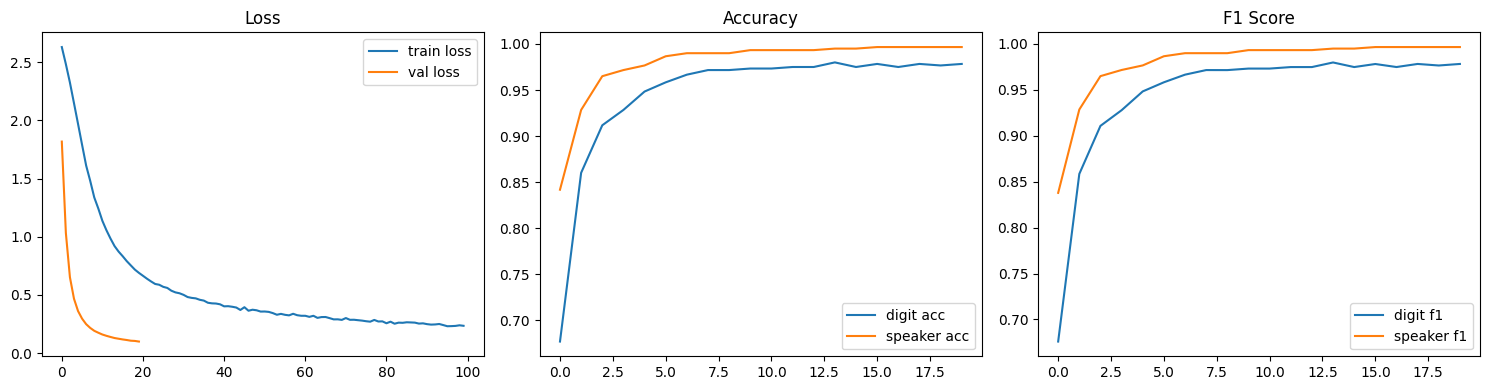

In [16]:

# Load model terbaik setelah training
model.load_state_dict(torch.load("best_model.pt"))

# Plot
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history["train_loss"], label="train loss")
axes[0].plot(history["val_loss"], label="val loss")
axes[0].set_title("Loss"); axes[0].legend()

axes[1].plot(history["digit_acc"], label="digit acc")
axes[1].plot(history["speaker_acc"], label="speaker acc")
axes[1].set_title("Accuracy"); axes[1].legend()

axes[2].plot(history["digit_f1"], label="digit f1")
axes[2].plot(history["speaker_f1"], label="speaker f1")
axes[2].set_title("F1 Score"); axes[2].legend()

plt.tight_layout()
plt.show()